# Code to evaluate calculations from Section 3 of Cao,Friedrich,Girard,Loizeau,Singh (2026)
## Section 1: exactly solving for $\rho_r$ as a function of $\rho_{\mathrm{total}}$ and $\rho_{\mathrm{qubit}}$
## Section 2: finding an approximate solution $\rho_r$ that is a proper density (as opposed to pseudo-density)
## Section 3: computing lower bound for interaction strength $\mathrm{Tr}(\hat H_{\mathrm{int}}^2)$
##### When designing this notebook we benefitted from interaction with GPT-5.

In [1]:
import matplotlib.pyplot as plt

import cupy as cp
import numpy as np

from scipy.special import binom
from scipy.special import jn_zeros
from scipy.integrate import quad
from scipy.special import j1


## Section 1: exactly solving for $\rho_r$ as a function of $\rho_{\mathrm{total}}$ and $\rho_{\mathrm{qubit}}$

In [2]:

def ft_j1_over_cos_fast(x, a, n_poles=40, eps=1e-12, limit=200, mode='Wigner'):
    """
    Principal-value ∫_{−∞}^{∞} J1(2k)/(k*2*cos(a k)) e^{ikx} dk  (real output).

    Parameters
    ----------
    x : float
        Spatial point where the FT is evaluated.
    a : float (non-zero)
        Shift parameter in the denominator.
    n_poles : int
        How many pole intervals (on k>0) to integrate over exactly.
        More → safer for large |x|.
    eps : float
        Tiny offset so we stop short of each pole (avoids overflow).
    limit : int
        QUADPACK subdivision limit per sub-integral.

    Returns
    -------
    float
        The Cauchy principal value of the transform at x.
    """
    if a == 0.0:
        raise ValueError("a must be non-zero.")
    # integrand on k≥0  (even → FT = 2∫₀^∞ f(k)cos(kx)dk)
    if mode == 'Wigner':
        def g(k):
            return j1(2.0 * k) / (k * 2.0 * np.cos(a * k))/np.pi
    if mode == 'Gauss':
        def g(k):
            #return np.exp(-0.5*k**2/3.0**2)/ np.cos(a * k)
            return np.exp(-0.5*k**2/5.0**2) * np.cos(k) / np.cos(a * k)

    k0 = np.pi / (2.0 * a)          # first pole position
    total = 0.0
    # integrate piecewise between successive poles
    for m in range(n_poles):
        left = k0 * (2*m)
        next_left = k0 * (2*m + 2)
        right = k0 * (2*m + 1) - eps
        #
        # Note: we are adding here the integrands from both sides of the poles.
        #       i.e. we are simultaneously integrating from both sides.
        #       This makes the integral numerically more well behaved, because
        #       the +/- infinities to either side of the pole cancel each other
        #
        total += quad(lambda k: g(k) * np.cos(k * x) + g(next_left - (k-left)) * np.cos((next_left - (k-left)) * x),
                      left, right, limit=limit)[0]
    #
    return 2.0 * total              # recover full (−∞,∞) integral
# ------------------------------------------------------------


def residue_series(x, a, M=500):
    """
    The residue-series term  (iπ sgn(x)/(2a)) Σ (...) e^{ik_m x}.
    """
    if a == 0:
        raise ValueError("a must be non-zero.")

    x   = np.atleast_1d(x)
    sgn = np.sign(x)                         # sgn(0)=0 → whole term vanishes
    pref = 1j * np.pi / (2.0 * a) * sgn      # ← corrected factor 1/(2a)

    m   = np.arange(-M, M + 1, dtype=float)
    km  = (np.pi / (2.0 * a)) * (2.0 * m + 1.0)
    coeff = (-1.0)**(m + 1) * j1(2.0 * km) / km

    phase  = np.exp(1j * np.outer(km, x))
    series = (coeff[:, None] * phase).sum(axis=0)
    return pref * series                     # complex nd-array (same shape as x)

In [3]:
def semi_circle(x_values):
    indxs = np.where(x_values**2 < 4.0)[0]
    out = np.zeros_like(x_values)
    out[indxs] = np.sqrt(4.0-x_values[indxs]**2)/(2*np.pi)
    return out

In [4]:

x_max = 4.0
Nx = 400

x_values = np.linspace(-x_max, x_max,Nx)
dx = x_values[1]-x_values[0]
p0 = semi_circle(x_values)

a_vals = np.pi/jn_zeros(1,6)

a_rough = a_vals[2]
n_shift = int(a_rough/dx)
a = n_shift*dx
f = np.zeros_like(p0)
for i in range(0,len(x_values)):
    if i%20 == 0:
        print(i,'/',Nx)
    f[i] = ft_j1_over_cos_fast(x_values[i], a, n_poles=1600, eps=1e-16, limit=1600,mode='Wigner')

print(a)


0 / 400
20 / 400
40 / 400
60 / 400
80 / 400
100 / 400
120 / 400
140 / 400
160 / 400
180 / 400
200 / 400
220 / 400
240 / 400
260 / 400
280 / 400
300 / 400
320 / 400
340 / 400
360 / 400
380 / 400
0.3007518796992481


(-4.4, 8.0)

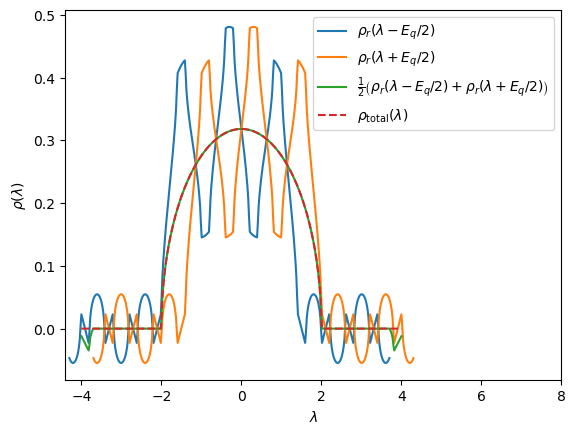

In [5]:

plt.plot(x_values-a, f,label=r'$\rho_r(\lambda - E_q/2)$')
plt.plot(x_values+a, f,label=r'$\rho_r(\lambda + E_q/2)$')

yy = np.interp(x_values, x_values-a, f)
yy += np.interp(x_values, x_values+a, f)
plt.plot(x_values, 0.5*yy,label=r'$\frac{1}{2}\left(\rho_r(\lambda - E_q/2)+\rho_r(\lambda + E_q/2)\right)$')
plt.plot(x_values, p0,label=r'$\rho_{\mathrm{total}}(\lambda)$',linestyle='dashed')

plt.xlabel(r'$\lambda$')
plt.ylabel(r'$\rho(\lambda)$')
plt.legend()

plt.xlim(-4.4, 8)


## Section 2: finding an approximate solution $\rho_r$ that is a proper density (as opposed to pseudo-density)
### The function return_matrix_from_dp_to_dlambda is based on calculating the $i$th value of a spectrum from the spectral density $p_0$ via 
### $\lambda_i = \frac{\int_{x_{i-1/2}}^{x_{i+1/2}} \mathrm{d}x\ x\ p_0(x)}{\int_{x_{i-1/2}}^{x_{i+1/2}} \mathrm{d}x\  p_0(x)} \equiv \frac{1}{P_i}\int_{x_{i-1/2}}^{x_{i+1/2}} \mathrm{d}x\ x\ p_0(x)$ .
### Taking the variation of this wrt. $p_0$ yields a map from an array of values of $\delta p$ to an array of values of $\delta \lambda$ . Squaring this matrix then yields the quadratic problem we have been solving in Section 3 of our paper.
### See inline comment in return_matrix_from_dp_to_dlambda for further details.



In [6]:


# ================================================================
# Utilities
# ================================================================

def _is_reflection_symmetric(x, p, rtol=1e-10, atol=1e-12):
    """
    Check whether (x, p) are symmetric under reflection about
    the grid midpoint.

    Parameters
    ----------
    x : cupy.ndarray, shape (n,)
        Grid points on device (monotone).
    p : cupy.ndarray, shape (n,)
        PDF values on the same grid.
    rtol, atol : float
        Tolerances for np.allclose.

    Returns
    -------
    bool
        True if grid and pdf look reflection-symmetric, else False.
    """
    xh = cp.asnumpy(x); ph = cp.asnumpy(p)
    n = xh.size
    rev = np.arange(n)[::-1]
    xm = 0.5 * (xh[0] + xh[-1])
    if not np.allclose(xh + xh[rev], 2.0 * xm, rtol=rtol, atol=atol):
        return False
    return np.allclose(ph, ph[rev], rtol=rtol, atol=10*atol)


def infer_dx_uniform_x(x, rtol=1e-9):
    """
    Infer uniform grid spacing dx from x (on device) and validate uniformity.

    Parameters
    ----------
    x : cupy.ndarray, shape (n,)
        Monotonically increasing grid points on device.
    rtol : float
        Relative tolerance for uniformity of np.diff(x).

    Returns
    -------
    dx : float
        Inferred uniform spacing (host float).

    Raises
    ------
    ValueError
        If the grid is not approximately uniform.
    """
    diffs = cp.diff(x)
    dx = float(diffs[0].get())
    if not np.allclose(cp.asnumpy(diffs), dx, rtol=rtol, atol=0.0):
        raise ValueError("x must be (approximately) uniformly spaced.")
    return dx


def return_matrix_from_dp_to_dlambda(p0, x):
    """
    Returns a matrix that maps vector of delta p to vector of delta lambda,
    when lambda is calculated as an average over a quantile of p, as in equations
    45 and 46 of Cao,Friedrich,Girard,Loizeau,Singh (2026).

    Note that we treat every element of array p0 as the PDF at the center of one such
    quantile. This is different from the paper, where we said we consider a set number of
    quantiles which all have the same probability. 
    (We find that the method here is in practice more robust.)

    Parameters
    ----------
    x : cupy.ndarray, shape (n,)
        grid points in lambda grid
    p0 : cupy.ndarray, shape (n,)
        spectral density at the points of x

    Returns
    -------
    K : cupy.ndarray, shape (n, n)
        matrix that maps from dp to dlambda
    """
    n = x.size
    K = cp.zeros((n, n), dtype=x.dtype)
    dx = infer_dx_uniform_x(x)
    indxs = np.where(p0 > 0.0)[0]
    for l in range(0,len(indxs)):
        # 
        # The ith eigenvalue \lambda_i is considered here as the
        # average over the ith in an list of quantiles, i.e.
        # \lambda_i = \int_{x_{i-1/2}}^{x_{i+1/2}} dx x p_0(x) / \int_{x_{i-1/2}}^{x_{i+1/2}} dx p_0(x)
        #           =: \int_{x_{i-1/2}}^{x_{i+1/2}} dx x p_0(x) / P_i
        # 
        # \delta \lambda will then contain terms ~ \delta p and terms ~\delta x_{i\pm 1/2}
        # where the last terms come from the fact that changes in p change the quantile boundaries.
        # 
        # But we can express \delta x_{i\pm 1/2} in terms of \delta p by taking the variation
        # of the equations
        # const = \int_{-\infty}^{\delta x_{i\pm 1/2}} dx p(x)
        # const = \int_{\delta x_{i\pm 1/2}}^{\infty} dx p(x)
        #
        # => This is what goes into the calculation below:
        #
        i = indxs[l]
        pi  = p0[i]
        pim = 0.5*pi
        pip = 0.5*pi
        if i > 0:
            pim = 0.5*(p0[i] + p0[i-1])
        if i < n-1:
            pip = 0.5*(p0[i] + p0[i+1])
        Pi  = dx*pi
        ri  = x[i]
        rim = ri-0.5*dx
        rip = ri+0.5*dx
        #
        K[i, i]     = dx*ri/Pi
        K[i, :i]   += 0.5*dx*rim/Pi
        K[i, :i+1] -= 0.5*dx*rip/Pi
        K[i, i:]   -= 0.5*dx*rim/Pi
        if i < n-1:
            K[i, i+1:] += 0.5*dx*rip/Pi
        #
    return K

# ================================================================
# Quadratic model
# ================================================================

def build_quadratic_problem_data_cupy(p0, x, n_shift, wrap=False, enforce_reflection="auto"):
    """
    Build A, q, c on GPU (with optional reflection symmetrization) for

        L(f) = f^T A f + q^T f + c,

    where p1(x) = 0.5 * (f(x-n) + f(x+n)) and
          L = (p1 - p0)^T M (p1 - p0),
    using the explicit M = Nq^2 * dx^2 * K^T K constructed from p0.

    Parameters
    ----------
    p0 : array_like, shape (n,)
        Baseline PDF on the grid (NumPy or CuPy; cast to CuPy).
    x : array_like, shape (n,)
        Uniform grid (NumPy or CuPy; cast to CuPy).
    Nq : int
        Number of quantiles used to build M.
    n_shift : int
        Integer grid shift corresponding to ±a.
    wrap : bool, optional
        If True, apply periodic wrap for shifts; else zero-pad.
    enforce_reflection : {"auto","always","never"}, optional
        Enforce reflection-invariance by averaging (A,q) with their flipped
        versions. "auto" enforces only if (x,p0) appear symmetric.

    Returns
    -------
    A : cupy.ndarray, shape (n, n)
        Quadratic coefficient matrix on device.
    q : cupy.ndarray, shape (n,)
        Linear term vector on device.
    c : float
        Constant term (host float).
    """
    p0 = cp.asarray(p0, dtype=cp.float64)
    x  = cp.asarray(x,  dtype=cp.float64)
    dx = infer_dx_uniform_x(x)
    N  = p0.size

    K = return_matrix_from_dp_to_dlambda(p0, x)
    M  = (K.T @ K)
    M  = 0.5 * (M + M.T)

    #
    # K maps from dp to dlambda.
    # But we want to go from df to dlambda, where
    # p(\lambda) = 1/2 (f(lambda-E_q/2) + f(lambda+E_q/2)).
    # 
    # Averaging over the appropriate shifts in M will then
    # yield that actual matrix A that has to go into our
    # quadratic problem.
    #
    #
    A = cp.zeros((N, N), dtype=cp.float64)
    idx = cp.arange(N)
    idx_plus, idx_minus = idx + n_shift, idx - n_shift
    if wrap:
        idx_plus %= N
        idx_minus %= N
        vp = vm = cp.ones(N, dtype=bool)
    else:
        def valid(a): return (a >= 0) & (a < N)
        vp, vm = valid(idx_plus), valid(idx_minus)

    # A_ij = 1/4 * sum over (i±n, j±n)
    masks_rows = [(idx_plus, vp), (idx_minus, vm)]
    masks_cols = masks_rows
    for (ri, rmask) in masks_rows:
        for (cj, cmask) in masks_cols:
            rows = ri[rmask]; cols = cj[cmask]
            if rows.size == 0 or cols.size == 0:
                continue
            block = M[cp.ix_(rows, cols)]
            A[cp.ix_(cp.where(rmask)[0], cp.where(cmask)[0])] += 0.25 * block

    A = 0.5 * (A + A.T)  # numeric symmetry

    Mp = M @ p0
    q = cp.zeros(N, dtype=cp.float64)
    if wrap:
        q = -(Mp[idx_plus] + Mp[idx_minus])
    else:
        if bool(vp.any()): q[vp] -= Mp[idx_plus[vp]]
        if bool(vm.any()): q[vm] -= Mp[idx_minus[vm]]

    c = float((p0 @ Mp).get())

    # Reflection symmetrization
    rev = cp.arange(N-1, -1, -1)
    need_sym = (enforce_reflection == "always") or \
               (enforce_reflection == "auto" and _is_reflection_symmetric_cupy(x, p0))
    if need_sym:
        A = 0.5 * (A + A[rev][:, rev])
        q = 0.5 * (q + q[rev])

    return A, q, c

# ================================================================
# GPU FISTA solver with corrected simplex projection
# ================================================================

def estimate_lambda_max(A, iters=80):
    """
    Estimate the largest eigenvalue of a symmetric PSD matrix A on GPU.

    Parameters
    ----------
    A : cupy.ndarray, shape (n, n)
        Symmetric positive semidefinite matrix.
    iters : int
        Power-iteration steps.

    Returns
    -------
    lam_max : float
        Approximate largest eigenvalue (host scalar).
    """
    N = A.shape[0]
    x = cp.random.random(N, dtype=A.dtype)
    x /= cp.linalg.norm(x)
    for _ in range(iters):
        y = A @ x
        x = y / (cp.linalg.norm(y) + 1e-32)
    return float((x @ (A @ x)).get())


def project_onto_simplex(f, dx):
    """
    Project vector f onto the simplex {f >= 0, sum(f)*dx = 1} on GPU, i.e. enforce
    that f is a density.

    Parameters
    ----------
    f : cupy.ndarray, shape (n,)
        Input vector on device.
    dx : float
        grid spacing.

    Returns
    -------
    proj : cupy.ndarray, shape (n,)
        Projection of f onto the simplex.
    """
    s = 1.0/dx
    N = f.size
    u = cp.sort(f)[::-1]
    cssv = cp.cumsum(u)
    j = cp.arange(1, N + 1)
    cond = u - (cssv - s) / j > 0
    idx = cp.nonzero(cond)[0]
    if idx.size == 0:
        theta = (cssv[0] - s)  # degenerate fallback
    else:
        rho = idx[-1]
        theta = (cssv[rho] - s) / (rho + 1)
    return cp.maximum(f - theta, 0.0)


def solve_qp_pdf_cupy_explicitM(p0, x, n_shift, wrap=False,
                                max_iter=50000, tol=1e-12,
                                estimate_lipschitz=True, L0=None,
                                enforce_reflection="auto", verbose=False):
    """
    GPU solver for the constrained QP:

        minimize    f^T A f + q^T f
        subject to  f >= 0,  sum(f)*dx = 1,

    with A built explicitly from p0 (dx inferred from x). Uses FISTA with
    simplex projection.
s
    Parameters
    ----------
    p0 : array_like, shape (n,)
        Baseline PDF on the grid.
    x : array_like, shape (n,)
        Uniform grid points.
    n_shift : int
        Integer grid shift for ±a.
    wrap : bool
        Use periodic boundary handling for shifts if True; otherwise zero-pad.
    max_iter : int
        Maximum FISTA iterations.
    tol : float
        Stopping tolerance (scaled infinity norm of gradient).
    estimate_lipschitz : bool
        If True, estimate 2*lambda_max(A) by power iteration.
    L0 : float or None
        If `estimate_lipschitz` is False, provide the Lipschitz constant.
    enforce_reflection : {"auto","always","never"}
        Whether to symmetry-average (A, q).
    verbose : bool
        Print diagnostic information.

    Returns
    -------
    f_opt : numpy.ndarray, shape (n,)
        Optimal PDF on host memory.
    """
    A, q, c, = build_quadratic_problem_data_cupy(
        p0, x, n_shift, wrap=wrap, enforce_reflection=enforce_reflection
    )
    grad = lambda f: 2.0 * (A @ f) + q

    if estimate_lipschitz:
        lam_max = estimate_lambda_max(A)
        L = max(2.0 * lam_max, 1e-6)
    else:
        if L0 is None:
            raise ValueError("Provide L0 when estimate_lipschitz=False.")
        L = float(L0)

    N = A.shape[0]
    f = cp.full(N, 1 / (N*dx), dtype=A.dtype)
    y, t = f.copy(), 1.0
    obj = lambda fv: float((fv @ (A @ fv) + q @ fv).get())

    best, f_best = obj(f), f.copy()
    for it in range(max_iter):
        g = grad(y)
        #
        # at each gradient descent step: 
        # enforce positivity and normalisation
        #
        f_next = project_onto_simplex(y - (1.0 / L) * g, dx)
        #
        # In FISTA, the next gradient is computed
        # at a slightly extrapotated point (not at 
        # f_next...). Hence the following code:
        #
        t_next = 0.5 * (1 + np.sqrt(1 + 4 * t * t))
        y = f_next + ((t - 1) / t_next) * (f_next - f)
        f, t = f_next, t_next
        if (it + 1) % 25 == 0 or it == 0:
            val = obj(f)
            if val < best:
                best, f_best = val, f.copy()
            if cp.linalg.norm(g, ord=cp.inf) / (1.0 + abs(best)) < tol:
                break
    return cp.asnumpy(f_best) 


In [7]:
def semi_circle(x_values):
    indxs = np.where(x_values**2 < 4.0)[0]
    out = np.zeros_like(x_values)
    out[indxs] = np.sqrt(4.0-x_values[indxs]**2)/(2*np.pi)
    return out

def mp_density(lam, gamma):
    """
    Marchenko–Pastur (MP) density for the ESD of S = (1/p) X X^*
    in the limit n,p->infty with n/p -> gamma > 0.

    Parameters
    ----------
    lam : array_like
        Points (eigenvalue locations) at which to evaluate the MP density.
        Should be nonnegative for the MP law.
    gamma : float
        Aspect ratio gamma = n/p (positive).

    Returns
    -------
    dens : np.ndarray
        MP density f_gamma(lam) evaluated pointwise.
        Note: if gamma > 1, the limiting measure has an additional atom at 0
        with mass (1 - 1/gamma), not represented by this density.
    a, b : float
        Support endpoints of the continuous part: [a, b].
    """
    lam = np.asarray(lam, dtype=float)
    if gamma <= 0:
        raise ValueError("gamma must be positive")
    #
    sg = np.sqrt(gamma)
    a = (1.0 - sg) ** 2
    b = (1.0 + sg) ** 2
    #
    dens = np.zeros_like(lam)
    #
    # mask for the continuous support
    mask = (lam >= a) & (lam <= b) & (lam > 0)
    # sqrt((b-lam)(lam-a)) but clipped for numerical stability
    rad = (b - lam[mask]) * (lam[mask] - a)
    rad = np.maximum(rad, 0.0)
    #
    dens[mask] = np.sqrt(rad) / (2.0 * np.pi * gamma * lam[mask])
    return dens, a, b

def log_mp_density(lam, gamma):
    sg = np.sqrt(gamma)
    a = (1.0 - sg) ** 2
    b = (1.0 + sg) ** 2
    dens = np.zeros_like(lam)
    #
    mask = (np.exp(-lam) >= a) & (np.exp(-lam) <= b) & (np.exp(-lam) > 0)
    # sqrt((b-lam)(lam-a)) but clipped for numerical stability
    rad = (b - np.exp(-lam[mask])) * (np.exp(-lam[mask]) - a)
    rad = np.maximum(rad, 0.0)
    #
    dens[mask] = np.sqrt(rad) / (2.0 * np.pi * gamma)
    return dens, a, b
    

def Gaussian(x_values, mu=0.0, sigma=1.0):
    indxs = np.where(x_values**2 > (4.0*sigma)**2)[0]
    out = np.exp(-0.5*(x_values-mu)**2/sigma**2)/np.sqrt(2*np.pi*sigma**2)
    return out
    #out[indxs] *= 0.0
    norm = np.sum(0.5*(out[1:] + out[:-1])*(x_values[1:] - x_values[:-1]))
    return out/norm


In [8]:

x_max = 4.0
Nx = 4096+1

x_values = np.linspace(-x_max, x_max,Nx)
dx = x_values[1]-x_values[0]
p0 = semi_circle(x_values)
#p0 = Gaussian(x_values)

a_vals = np.pi/jn_zeros(1,6)

a_rough = a_vals[2]
n_shift = int(a_rough/dx)
a = n_shift*dx
f = solve_qp_pdf_cupy_explicitM(p0, x_values, n_shift, wrap=True, enforce_reflection="always")

print(a)

0.30859375


(-4.4, 8.0)

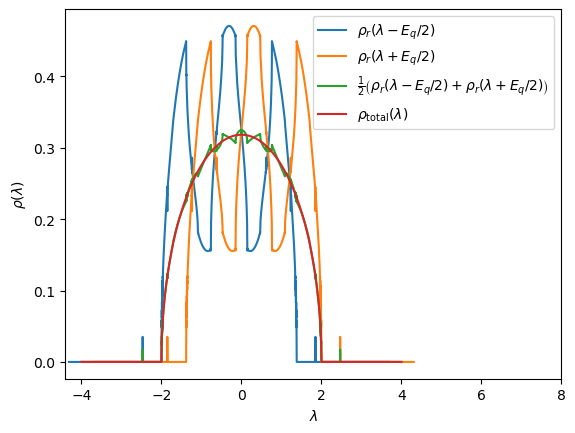

In [9]:

plt.plot(x_values-a, f,label=r'$\rho_r(\lambda - E_q/2)$')
plt.plot(x_values+a, f,label=r'$\rho_r(\lambda + E_q/2)$')

yy = np.interp(x_values, x_values-a, f)
yy += np.interp(x_values, x_values+a, f)
plt.plot(x_values, 0.5*yy,label=r'$\frac{1}{2}\left(\rho_r(\lambda - E_q/2)+\rho_r(\lambda + E_q/2)\right)$')
plt.plot(x_values, p0,label=r'$\rho_{\mathrm{total}}(\lambda)$')

plt.xlabel(r'$\lambda$')
plt.ylabel(r'$\rho(\lambda)$')
plt.legend()

plt.xlim(-4.4, 8)


## Section 3: computing lower bound for interaction strength $\mathrm{Tr}(\hat H_{\mathrm{int}}^2)$

In [10]:


# ================================================================
# NEW: Loss evaluation
# ================================================================

def _shift_apply_cupy(vec, n_shift, wrap):
    """
    Apply integer grid shift to a vector on device.

    Parameters
    ----------
    vec : cupy.ndarray, shape (n,)
        Vector to shift.
    n_shift : int
        Shift in grid steps (positive = to the right).
    wrap : bool
        If True, wrap indices; else zero-pad out-of-range.

    Returns
    -------
    shifted : cupy.ndarray, shape (n,)
        Shifted vector.
    """
    N = vec.size
    idx = cp.arange(N)
    if wrap:
        return vec[(idx - n_shift) % N]
    # zero-padding
    out = cp.zeros_like(vec)
    src = idx - n_shift
    mask = (src >= 0) & (src < N)
    out[mask] = vec[src[mask]]
    return out


def compute_loss_cupy(p0, f, x, n_shift, wrap=False):
    """
    Compute the loss L = sum_i (delta_mu_i)^2 directly from p0 and f.

    This uses the explicit M derived from p0's quantiles so that

        delta_mu = Nq * dx * K @ (p1 - p0),
        L        = (p1 - p0)^T M (p1 - p0),

    where p1 = 0.5*(f(·-n) + f(·+n)) under the chosen boundary rule.

    Parameters
    ----------
    p0 : array_like, shape (n,)
        Baseline PDF on the grid (NumPy or CuPy; cast to CuPy).
    f : array_like, shape (n,)
        Candidate PDF (must satisfy sum(f)*dx=1 and f>=0 for a valid pdf).
    x : array_like, shape (n,)
        Uniform grid points (NumPy or CuPy; cast to CuPy).
    Nq : int
        Number of quantiles defining the loss.
    n_shift : int
        Grid shift corresponding to ±a.
    wrap : bool, optional
        Use periodic wrap for shifts if True; otherwise zero-pad.
    return_deltamu : bool, optional
        If True, also return the vector of delta_mu_i values.

    Returns
    -------
    L : float
        Loss value (squared difference of quantile means).
    delta_mu : numpy.ndarray, shape (Nq,), optional
        Only if `return_deltamu=True`. The per-quantile mean differences.

    Notes
    -----
    - This function **does not** modify/renormalize `f`. If `f` is not a valid
      pdf on the grid (nonnegative and sum(f)*dx = 1), the returned loss
      reflects that `p1` too is off-normalization.
    """
    # Cast
    p0 = cp.asarray(p0, dtype=cp.float64)
    f  = cp.asarray(f,  dtype=cp.float64)
    x  = cp.asarray(x,  dtype=cp.float64)

    # Build M consistently with the rest of the pipeline
    K = return_matrix_from_dp_to_dlambda(p0, x)
    M  = (K.T @ K)
    M  = 0.5 * (M + M.T)

    # Build p1 from f using shifts
    f_plus  = _shift_apply_cupy(f, +n_shift, wrap=wrap)
    f_minus = _shift_apply_cupy(f, -n_shift, wrap=wrap)
    p1 = 0.5 * (f_plus + f_minus)

    # Residual and loss
    v = p1 - p0
    L = float((v @ (M @ v)).get())
    
    return L


In [ ]:

j1_zeros = jn_zeros(1,6)
a_vals_fine = np.geomspace(np.pi/j1_zeros[0]/0.7, np.pi/j1_zeros[4]*0.7, 100)
a_vals_fine = np.geomspace(np.pi/j1_zeros[0]/0.7, np.pi/j1_zeros[4]*0.7, 30)
L_vals_fine = np.zeros_like(a_vals_fine)


for i in range(0,len(a_vals_fine)):
    x_max = 2.0+1.1*a_vals_fine[i]
    Nx = 2*8192+1
    Nx = 2*2048+1
    x_values = np.linspace(-x_max, x_max,Nx)
    dx = x_values[1]-x_values[0]
    p0 = semi_circle(x_values)
    a_rough = a_vals_fine[i]
    n_shift = int(a_rough/dx)
    a_vals_fine[i] = n_shift*dx
    f = solve_qp_pdf_cupy_explicitM(p0, x_values, n_shift, wrap=True, enforce_reflection="always")
    L = compute_loss_cupy(p0, f, x_values, n_shift, wrap=True)
    #
    L_vals_fine[i] = L/Nx
    print(i, (2*a_vals_fine[i])**2/4, L_vals_fine[i])




0 1.3701423974104552 0.06519157672934199
1 1.179294403829046 0.035650894366344936
2 1.016186165375991 0.016559121015090657
3 0.8738203337488767 0.005568275839172979
4 0.7519348501779725 0.000868556470171407
5 0.6474585296566976 0.0001220399703845878
6 0.5578056270688981 0.001202265734211139
7 0.48079567372476223 0.0027545135078903393
8 0.41288606739023137 0.0037432522400476357
9 0.35607131298899874 0.0034537263521910565
10 0.30575298822286934 0.002294592525285849
11 0.2637549587992822 0.0010372616866297043
12 0.2264050029851041 0.00018841958547130907
13 0.19534145679826456 1.0225434765353704e-05
14 0.16760649830352364 0.00020786613197302576
15 0.1446536285911311 0.0003658806065830787
16 0.12490487210373388 0.00026119528723871977
17 0.10716947170642448 5.784893112000796e-05
18 0.09195356492802426 4.92958212940811e-06
19 0.07955261046596013 6.412069509008024e-05
20 0.06835054744320049 6.131453851798544e-05


In [ ]:
plt.loglog((2*a_vals_fine)**2/4, L_vals_fine)

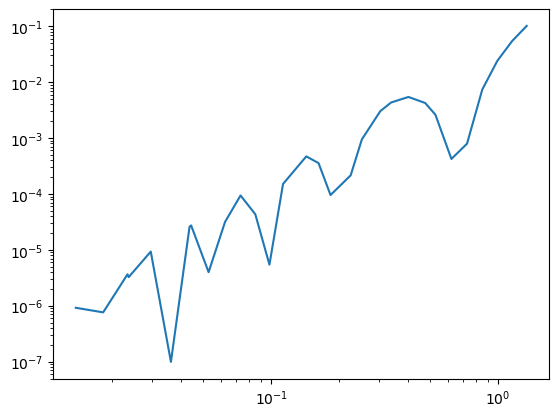

In [22]:
plt.loglog((2*a_vals_fine)**2/4, L_vals_fine)